# Análise Exploratória

In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

DATA_PATH = '../data/'
file_name = 'telco_customer_churn_silver.csv'
df_eda = pd.read_csv(DATA_PATH+file_name, sep=',')
df_eda.head(1)

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [2]:
TARGET_COLUMN = 'Churn'
NUMERIC_COLUMNS = ['Tenure', 'MonthlyCharges', 'TotalCharges']
CATEGORICAL_COLUMNS = []

for column in df_eda.columns:
    if column not in NUMERIC_COLUMNS and column != TARGET_COLUMN and column != 'CustomerID':
        CATEGORICAL_COLUMNS.append(column)

## Identificando proporção de Churn nos dados

### A distribuição da variável Churn é analisada para verificar a proporção de clientes que permaneceram (No) e que deixaram a empresa (Yes). Essa análise permite compreender a distribuição da variável-alvo e verificar se existe diferença significativa na quantidade de observações entre as classes antes.

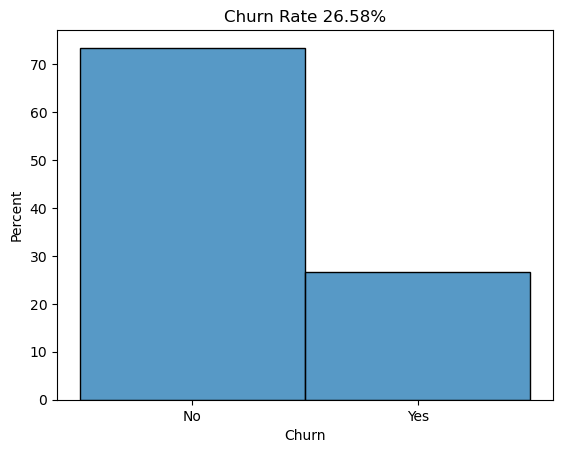

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

churn_count = df_eda[df_eda[TARGET_COLUMN] == 'Yes'].shape[0]
churn_rate = churn_count / df_eda.shape[0] * 100

fig, ax = plt.subplots()
ax.set_title(f'Churn Rate {churn_rate:.2f}%')
sns.histplot(data=df_eda, x=TARGET_COLUMN, stat='percent')
plt.show()

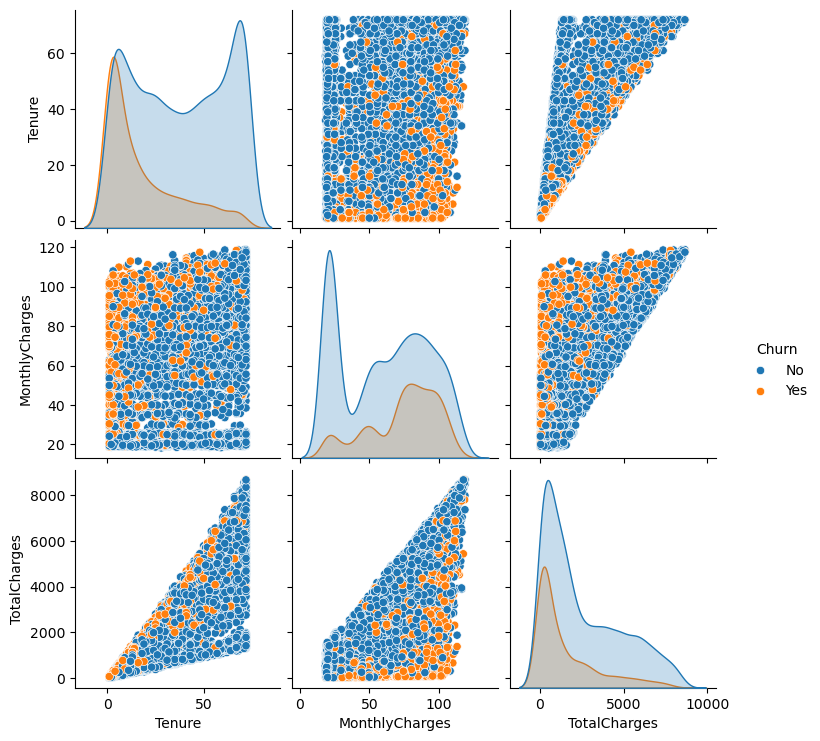

In [4]:
sns.pairplot(data=df_eda, hue=TARGET_COLUMN)

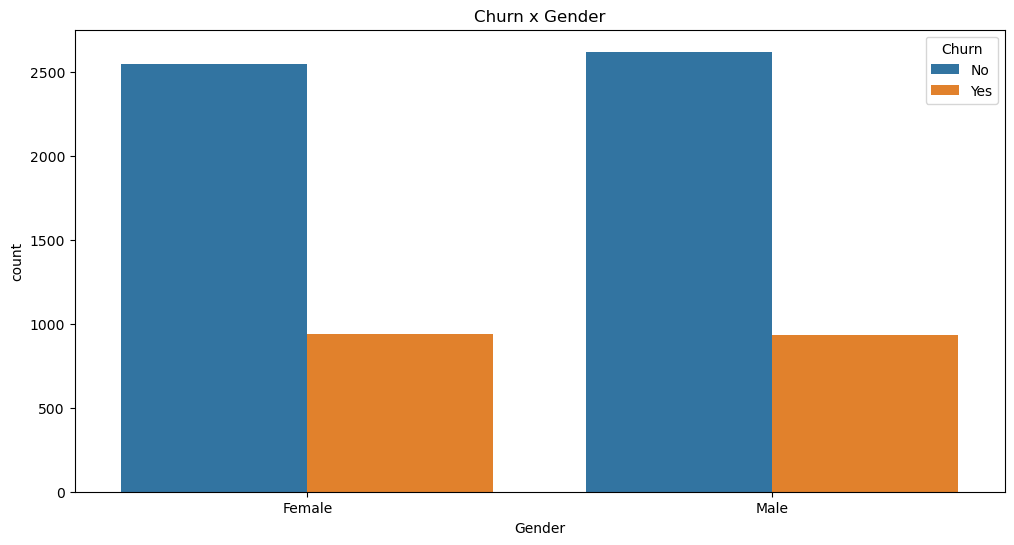

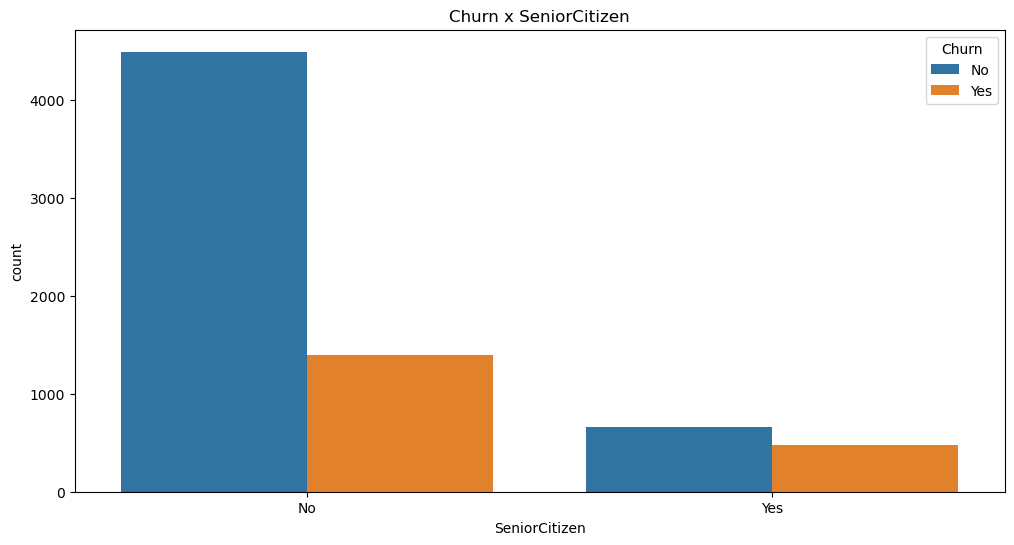

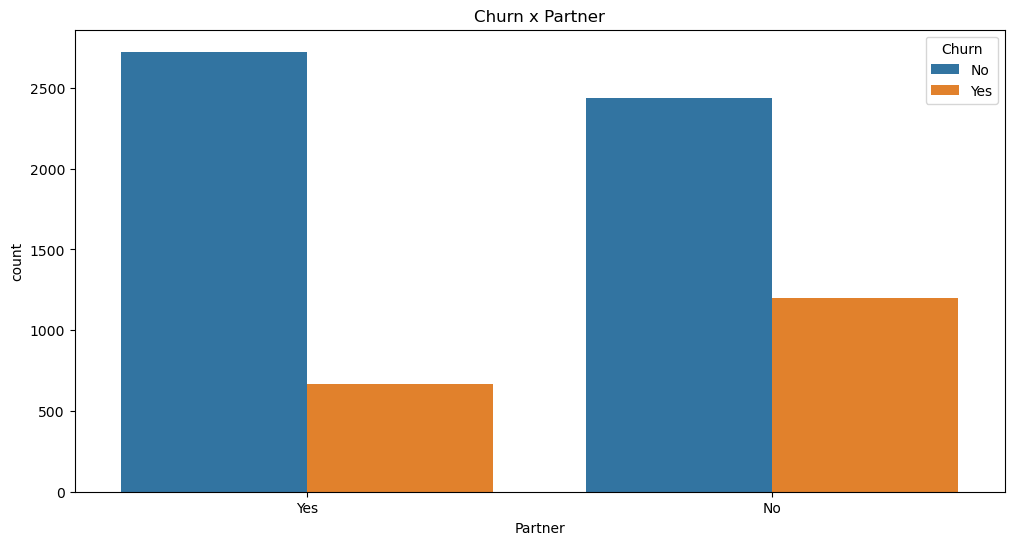

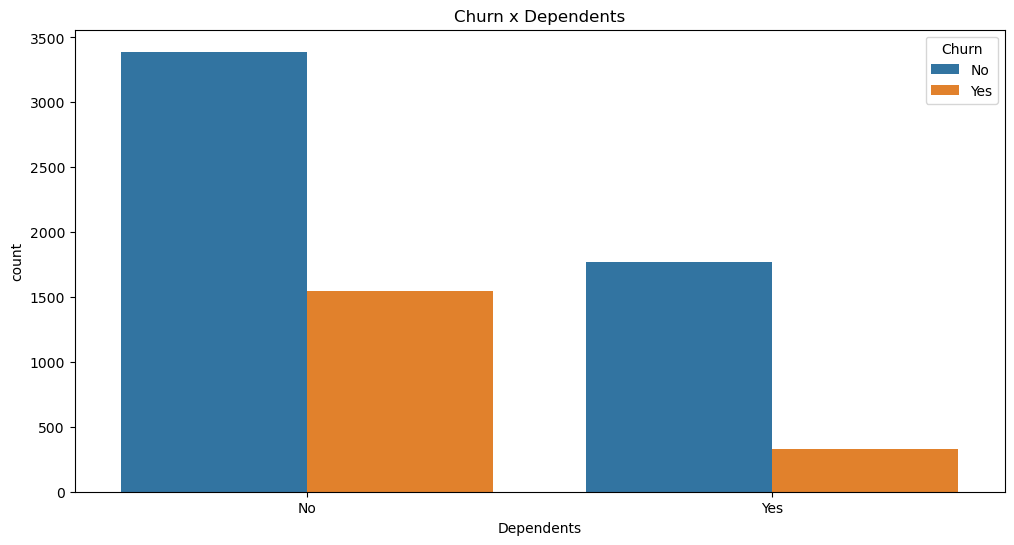

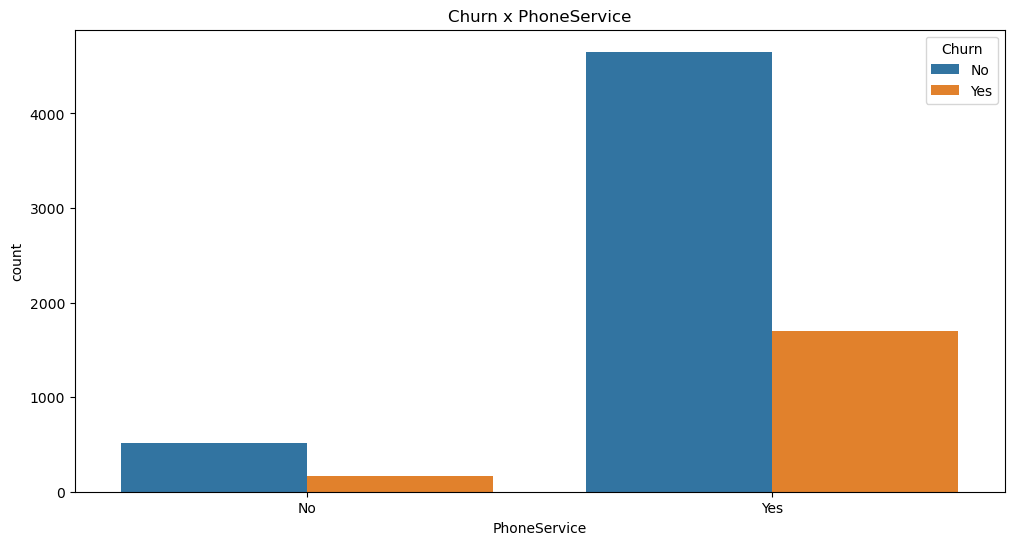

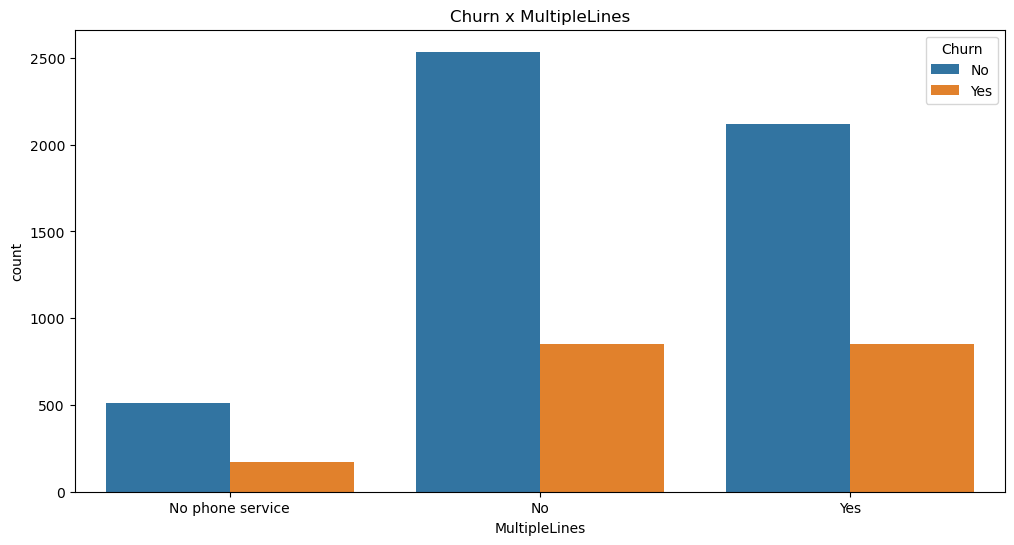

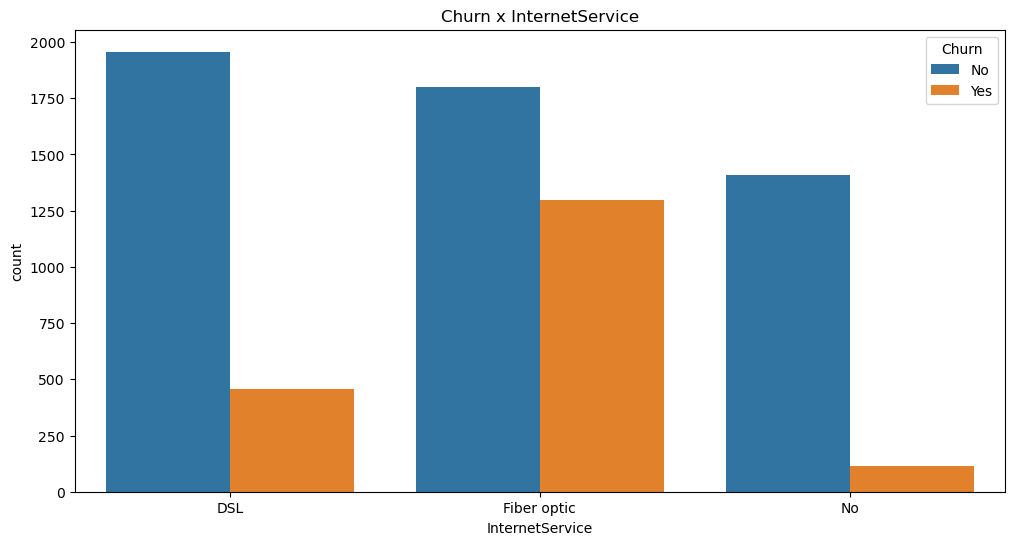

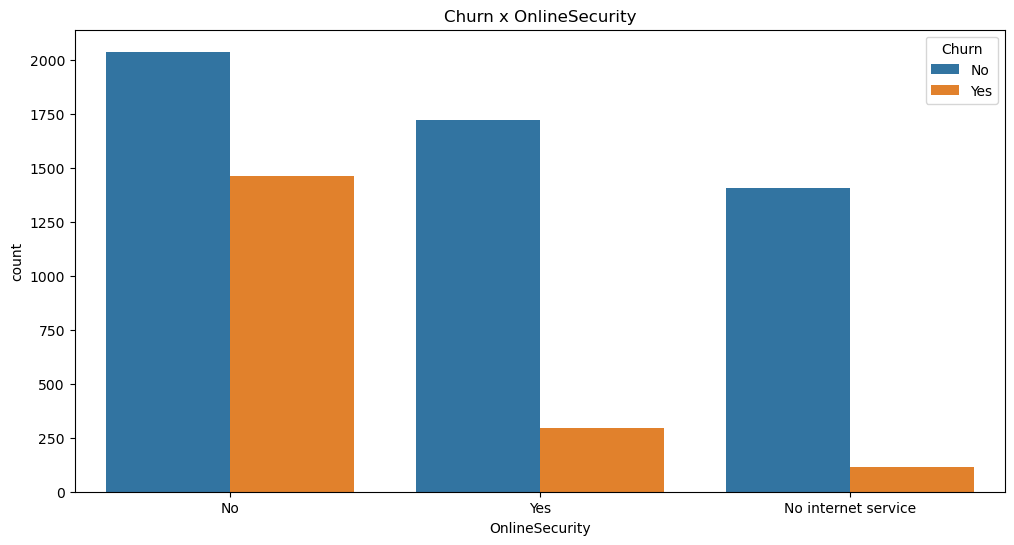

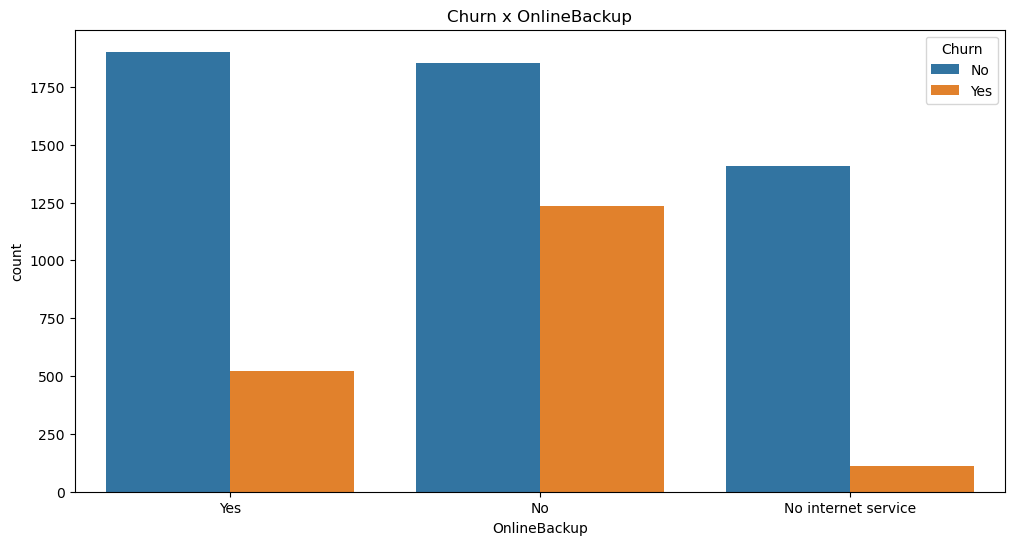

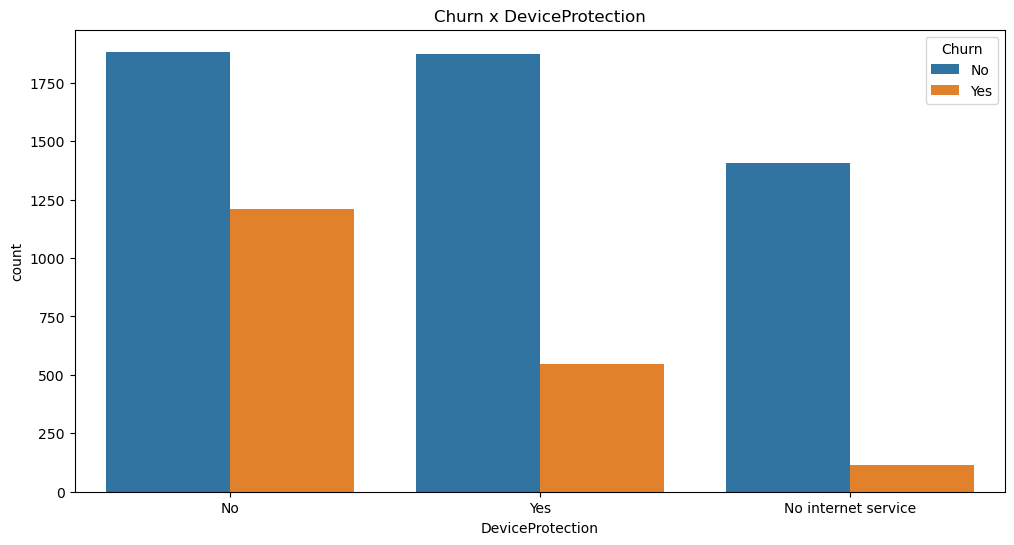

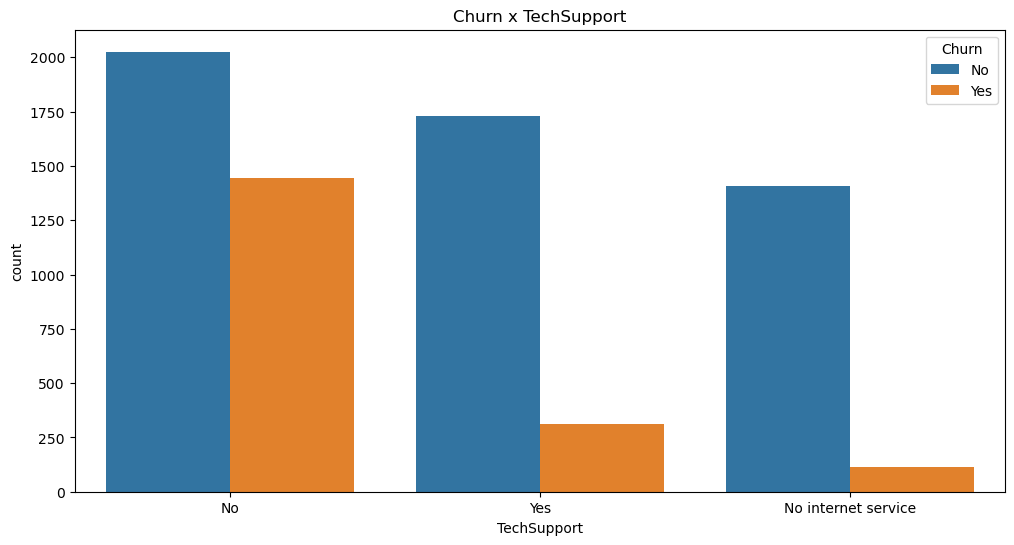

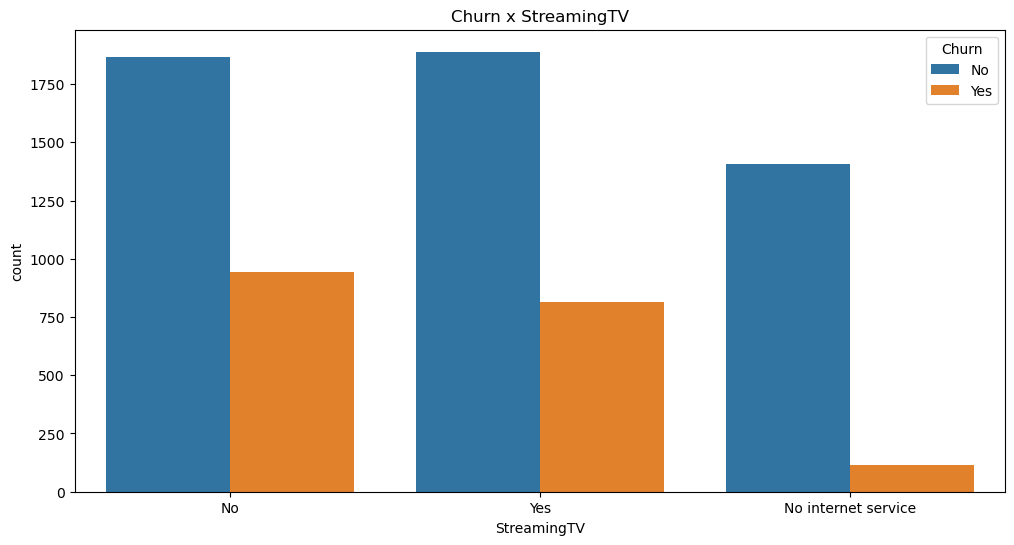

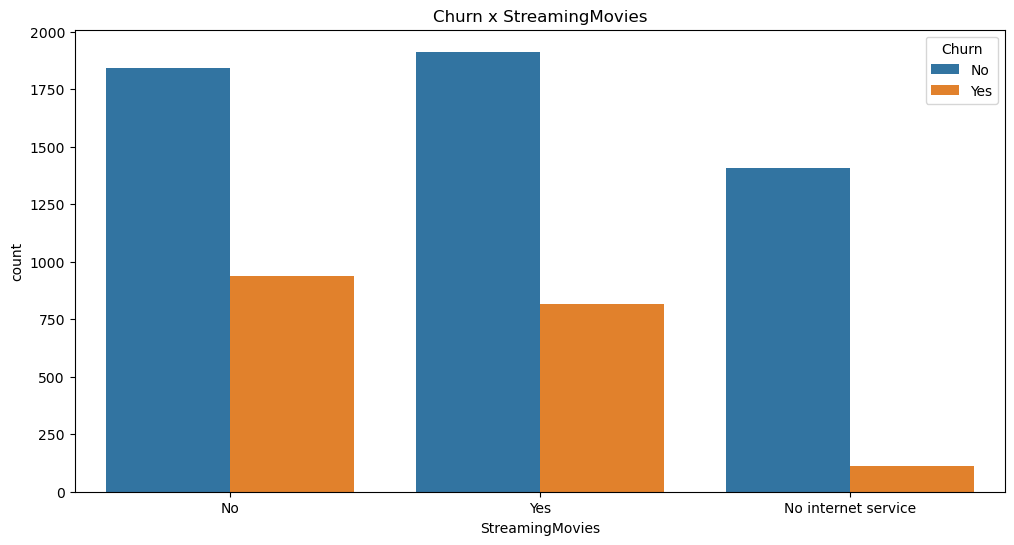

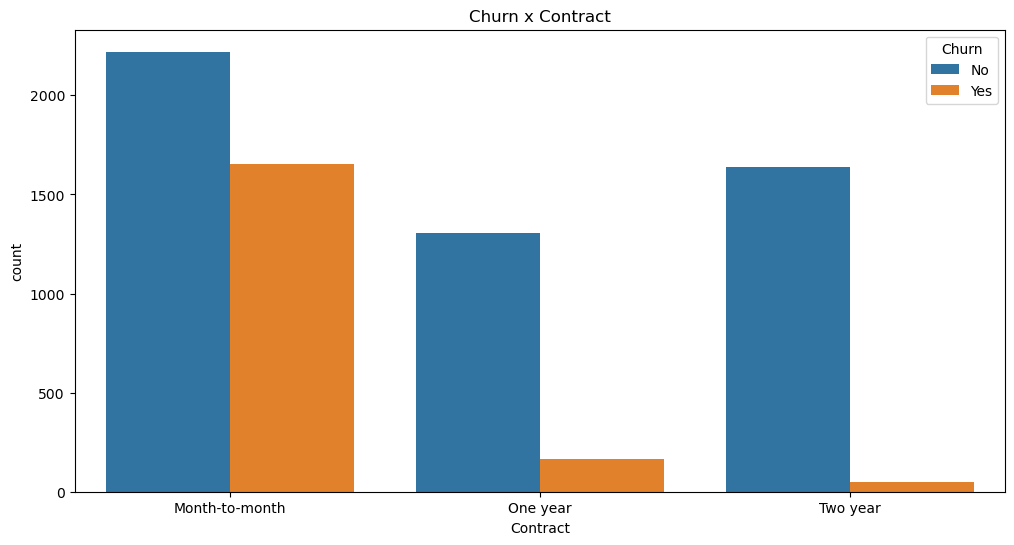

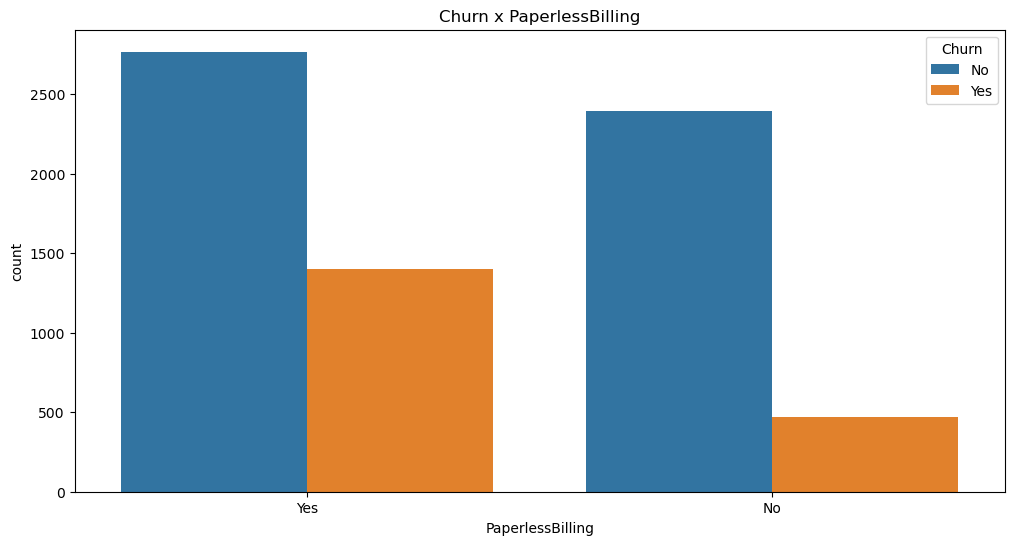

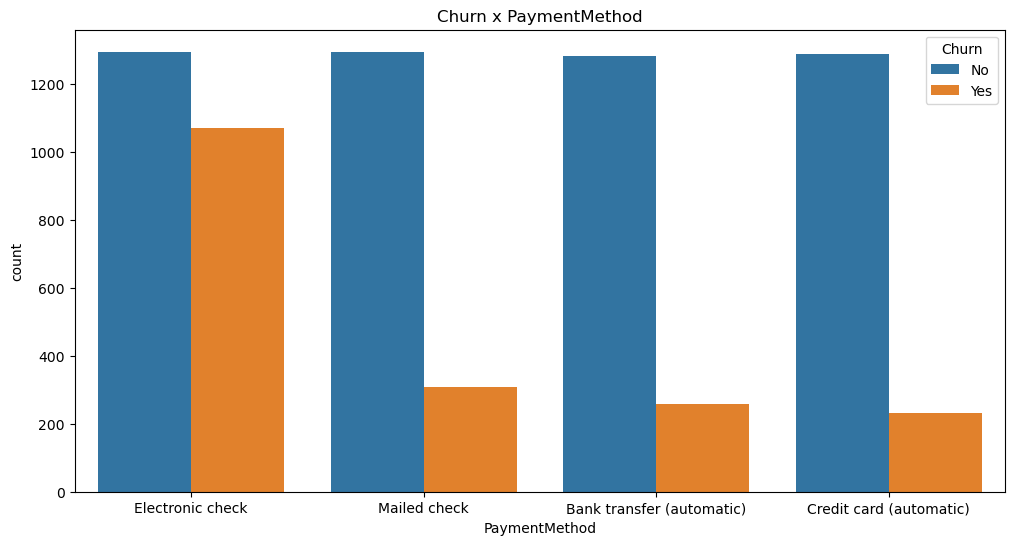

In [5]:
for column in CATEGORICAL_COLUMNS:
    fig, ax = plt.subplots(figsize=(12,6))
    
    sns.countplot(data=df_eda, x=column, hue=TARGET_COLUMN)
    
    ax.set_title(f'{TARGET_COLUMN} x {column}')
    ax.set_xlabel(column)
    plt.show()

### Identificada uma tendência de churn entre clientes com Tenure inferior a 10, indicando maior concentração de cancelamentos nesse período.

<Axes: xlabel='Tenure', ylabel='Count'>

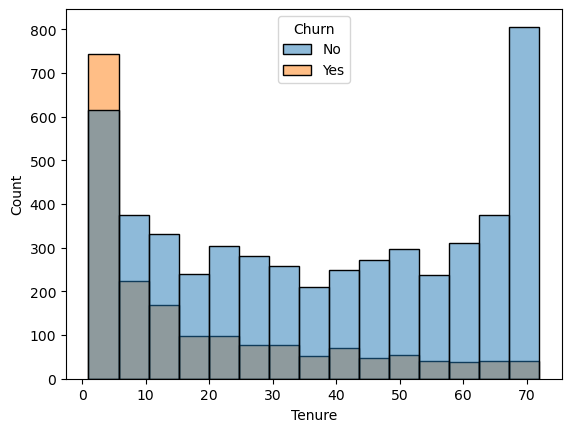

In [6]:
sns.histplot(data=df_eda, x='Tenure', hue=TARGET_COLUMN)

# Testes de hipóteses

In [7]:
import numpy as np
from scipy.stats import chi2_contingency

def chi2_test(column):
    # Criando a tabela de contingência (cruzamento das variáveis)
    contingency_table = pd.crosstab(df_eda[TARGET_COLUMN], df_eda[column])
    
    # Executando o Teste Qui-Quadrado
    chi2, p_valor, dof, expected = chi2_contingency(contingency_table)
    
    print(f"chi2: {chi2:.4f}")
    print(f"p-valor: {p_valor:.4f}")
    
    # Interpretacao do p-valor
    if p_valor < 0.05:
        print(f'Resultado: Existe uma associação estatisticamente significativa entre {TARGET_COLUMN} e {column}.')
    else:
        print(f'Resultado: Não Existe uma associação estatisticamente significativa entre {TARGET_COLUMN} e {column}.')
    
    # Calculando o V de Cramer (Força da associacao de 0 nenhuma associacao a 1 associacao perfeita)
    n = contingency_table.sum().sum() # Total de observacoes
    min_dim = min(contingency_table.shape) - 1 # Menor dimensao da tabela menos 1
    v_cramer = np.sqrt(chi2 / (n * min_dim)) # calcula v de cramer
    
    print(f"V de Cramer (Força da relação): {v_cramer:.4f} \n")

    # Calcula os Resíduos Padronizados
    #  Qualquer valor de resíduo maior que +2 ou menor que -2 indica um comportamento anormal e estatisticamente significante
    residuos = (contingency_table - expected) / np.sqrt(expected)
    display(residuos)

## Churn x InternetService

### O teste de Qui-Quadrado confirmou uma associação significativa entre o tipo de internet e o Churn (p < 0.001). A análise de resíduos padronizados comprova que o serviço Fiber Optic tem forte impacto no cancelamento entre os clientes que possuem InternetService, apresentando uma taxa de Churn de 41,9%, valor estatisticamente muito superior ao comportamento da DSL (19%) e de clientes sem internet (7,4%).

In [8]:
chi2_test('InternetService')

chi2: 728.6956
p-valor: 0.0000
Resultado: Existe uma associação estatisticamente significativa entre Churn e InternetService.
V de Cramer (Força da relação): 0.3219 



InternetService,DSL,Fiber optic,No
Churn,,,
No,4.348254,-9.944548,8.710626
Yes,-7.227054,16.528425,-14.477574


In [9]:
# O normalize='columns' divide os valores de cada célula pelo total daquela coluna
taxas_churn = pd.crosstab(df_eda[TARGET_COLUMN], df_eda['InternetService'], normalize='columns') * 100

print(f"Taxa de Churn interna da Fiber Optic: {taxas_churn.loc['Yes', 'Fiber optic']:.2f}%")
print(f"Taxa de Churn interna da DSL: {taxas_churn.loc['Yes', 'DSL']:.2f}%")
print(f"Taxa de Churn interna do Sem Internet: {taxas_churn.loc['Yes', 'No']:.2f}%")


Taxa de Churn interna da Fiber Optic: 41.89%
Taxa de Churn interna da DSL: 19.00%
Taxa de Churn interna do Sem Internet: 7.43%


## Churn x OnlineSecurity

### Descrever resultado

In [10]:
chi2_test('OnlineSecurity')

chi2: 846.6774
p-valor: 0.0000
Resultado: Existe uma associação estatisticamente significativa entre Churn e OnlineSecurity.
V de Cramer (Força da relação): 0.3470 



OnlineSecurity,No,No internet service,Yes
Churn,,,
No,-10.490220,8.710626,6.254151
Yes,17.435364,-14.477574,-10.394768
